In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Construct matrix A and its inverse
A = np.diag(4*np.ones(9)) + np.diag(-1*np.ones(8), 1) + np.diag(-1*np.ones(8), -1)
A[0,0] = 2
Ainv = np.linalg.inv(A)

In [3]:
# Initial condition
C = np.array([76.1, 40, 40, 40, 40, 40, 40, 40, 60])

# Time recursion (5 iterations)
D = np.zeros((9, 5))
for i in range(5):
    D[:, i] = np.dot(Ainv, C)
    C = np.empty(9)
    C[0] = 56.1 + D[0, i]
    C[1:8] = 2*D[1:8, i]
    C[8] = 2*D[8, i] + 20

(9, 6)


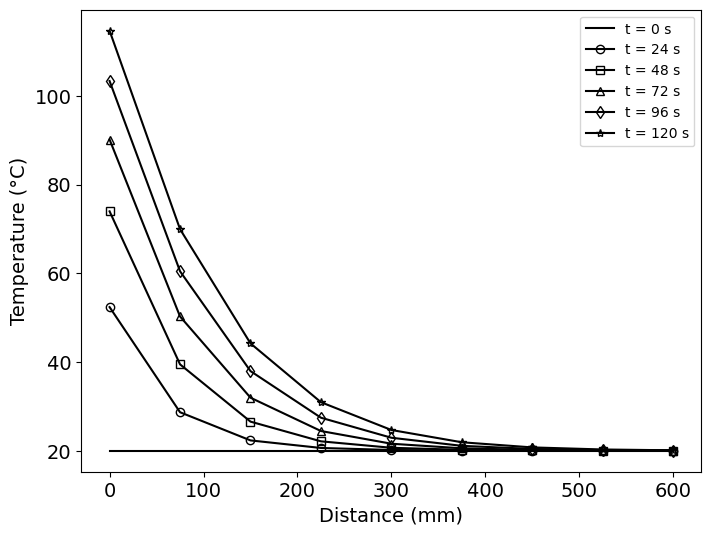

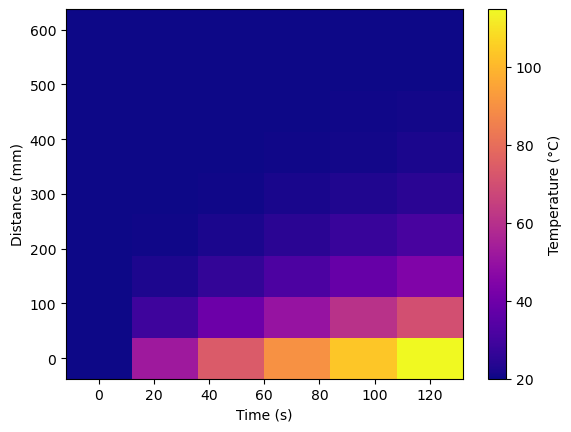

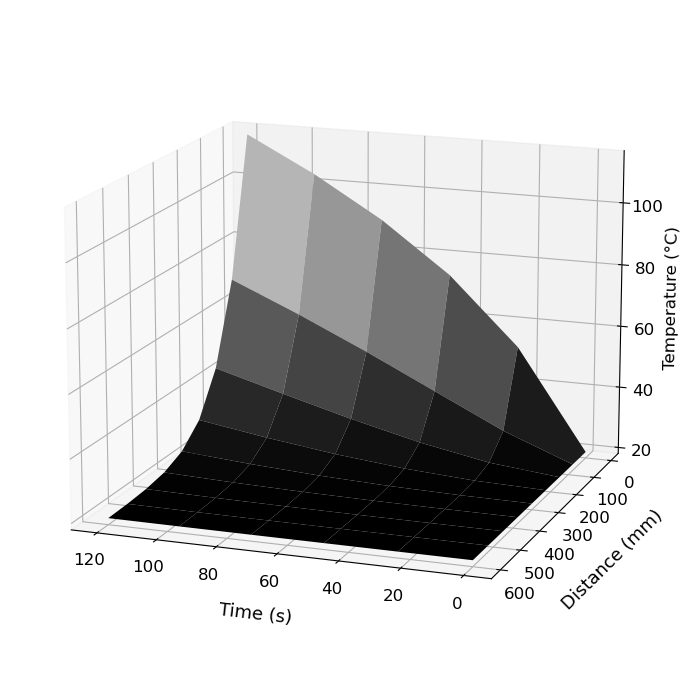

In [4]:
# FIGURES
# Prepare axis data
pos = np.arange(0, 601, 75)  # mm
tpo = np.arange(0, 121, 24)  # s
C0 = 20*np.ones(9)

plt.figure(1, figsize=(8, 6))
plt.plot(pos, C0, 'k', label='t = 0 s')
markers = ['o', 's', '^', 'd', '*']
for i in range(5):
    plt.plot(pos, D[:, i], color='k', marker=markers[i], fillstyle='none',
             label=f't = {24*(i+1)} s')
plt.xlabel('Distance (mm)', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=10)

# Figures 2 and 3
X, Y = np.meshgrid(tpo, pos)
Z = np.column_stack((C0, D))
print(Z.shape)

# 2D plot: Heat map
plt.figure(2)
plt.pcolormesh(X, Y, Z, cmap='plasma',
               vmin=np.nanmin(Z), vmax=np.nanmax(Z))
plt.colorbar(label='Temperature (°C)')
plt.xlabel('Time (s)')
plt.ylabel('Distance (mm)')

# 3D plot
fig = plt.figure(3, figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='gray',
                       vmin=np.nanmin(Z), vmax=np.nanmax(Z))
ax.set_xlabel('Time (s)', fontsize=13, labelpad=12)
ax.set_ylabel('Distance (mm)', fontsize=13, labelpad=12)
ax.set_zlabel('Temperature (°C)', fontsize=12)
ax.view_init(azim=110, elev=15)
plt.tick_params(axis='both', labelsize=12)
fig.tight_layout()

plt.show()